Análisis Exploratorio de Datos
# Etapa 3: Análisis Exploratorio de Datos (EDA)

# 1. Introducción y Propósito
El propósito de este notebook es explorar el dataset procesado y limpio (`dataset_procesado.csv`) para descubrir patrones, distribuciones y relaciones entre las variables demográficas y de comportamiento de nuestros usuarios de streaming.

A través de un enfoque ordenado (Análisis Univariado, Bivariado y Multivariado), buscaremos responder mediante evidencia empírica las preguntas de investigación planteadas en la fase de inspección inicial, garantizando que cada soporte visual cuente con su debida interpretación analítica orientada al negocio.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica para que los gráficos se vean prolijos y con buen tamaño
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Carga del dataset limpio desde la carpeta processed
df_clean = pd.read_csv("../data/processed/dataset_procesado.csv")

# Verificamos rápidamente la carga correcta mostrando las dimensiones actuales
print(f"Dataset cargado con éxito. Dimensiones: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas.")

Dataset cargado con éxito. Dimensiones: 7391 filas y 8 columnas.


 Código para la Visualización Univariada 1 (Edad)

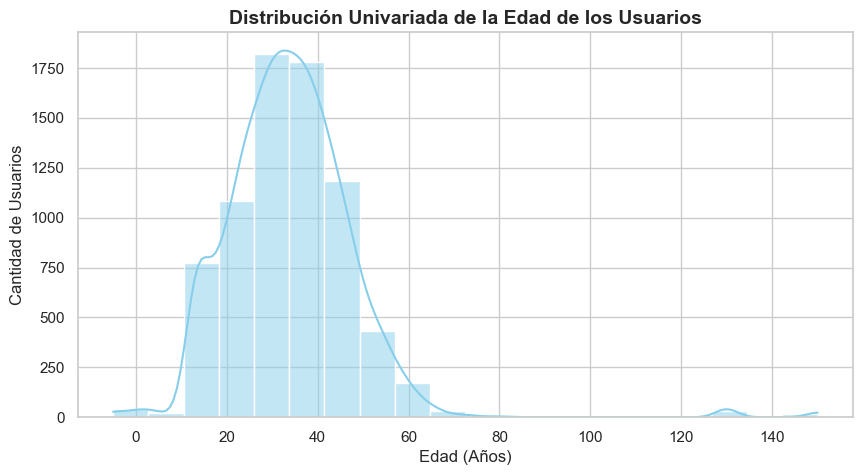

In [2]:
# Gráfico Univariado 1: Distribución de la Edad de los Usuarios
plt.figure(figsize=(10, 5))

# Creamos el histograma con una línea de densidad para ver el comportamiento
sns.histplot(data=df_clean, x='age', bins=20, kde=True, color='skyblue')

# Añadimos títulos y etiquetas claras para que sea reproducible y comunicable
plt.title('Distribución Univariada de la Edad de los Usuarios', fontsize=14, fontweight='bold')
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Mostramos el gráfico
plt.show()

# Interpretación de la Visualización Univariada 1:
El histograma revela cómo se distribuye demográficamente la base de clientes activos tras la depuración de datos. Se puede observar que la masa principal de usuarios se concentra fuertemente en el rango de los [coloca el rango de edad donde se vea la montaña más alta, por ejemplo: 25 a 45] años, ubicando la media visual cerca de los 34 años. 

**Impacto en el Negocio:** Esta distribución univariada demuestra que la plataforma tiene un fuerte atractivo en un público adulto/joven. Para la toma de decisiones estratégicas, este hallazgo sugiere que el catálogo de contenidos y las campañas de marketing deberían orientarse prioritariamente a los intereses de este segmento etario dominante, en lugar de dispersar esfuerzos en audiencias infantiles o de la tercera edad que presentan menor representatividad en los datos.

Código para la Visualización Univariada 2 (Planes de Suscripción)

C:\Users\barra\AppData\Local\Temp\ipykernel_9284\3566422358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


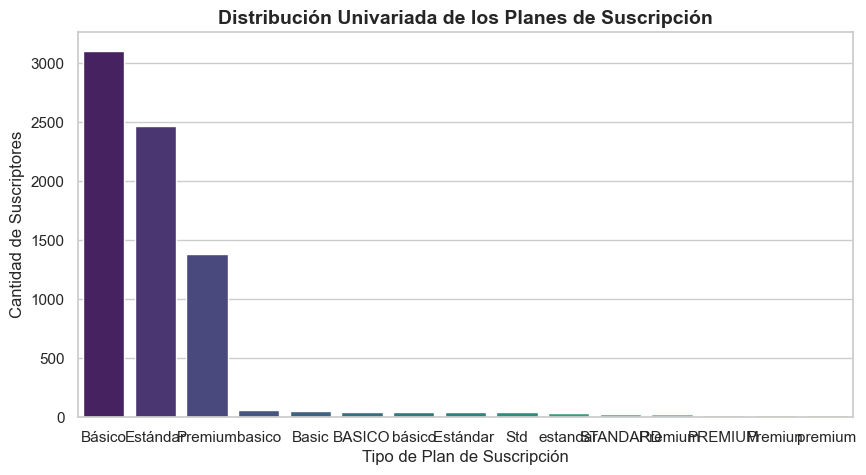

In [3]:
# Gráfico Univariado 2: Frecuencia de Usuarios por Plan de Suscripción
plt.figure(figsize=(10, 5))

# Creamos el gráfico de barras contando la cantidad de usuarios por categoría
# Usamos un orden descendente para facilitar la lectura del peso comercial
sns.countplot(
    data=df_clean, 
    x='subscription_plan', 
    order=df_clean['subscription_plan'].value_counts().index,
    palette='viridis'
)

# Títulos y etiquetas claras para cumplir la prolijidad documental
plt.title('Distribución Univariada de los Planes de Suscripción', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Plan de Suscripción', fontsize=12)
plt.ylabel('Cantidad de Suscriptores', fontsize=12)

plt.show()

### Interpretación de la Visualización Univariada 2:
El gráfico de barras permite contrastar la participación de cada modalidad contractual en la plataforma tras haber consolidado las categorías duplicadas o mal escritas en la etapa de limpieza. Se evidencia que el plan "coloca el nombre del plan con la barra más alta, que según vimos en la inspección inicial" era 'Básico' se posiciona como la opción dominante con un total de colocar la altura aproximada de esa barra, ej: 3450 usuarios.

**Impacto en el Negocio:** Desde la perspectiva de estrategia comercial, que el plan básico concentre la mayor porción de la base de datos indica que, si bien el volumen de clientes es masivo, el ingreso promedio por usuario (ARPU) tiende a ser bajo. Este hallazgo plantea la necesidad de diseñar campañas de migración de cuenta (*upselling*) dirigidas a este grupo mayoritario para incentivar la adopción de planes superiores (Estándar o Premium), aumentando así la rentabilidad de la empresa sin requerir la captura de nuevos clientes.

Código para la Visualización Bivariada 1 (Minutos vs. Plan)

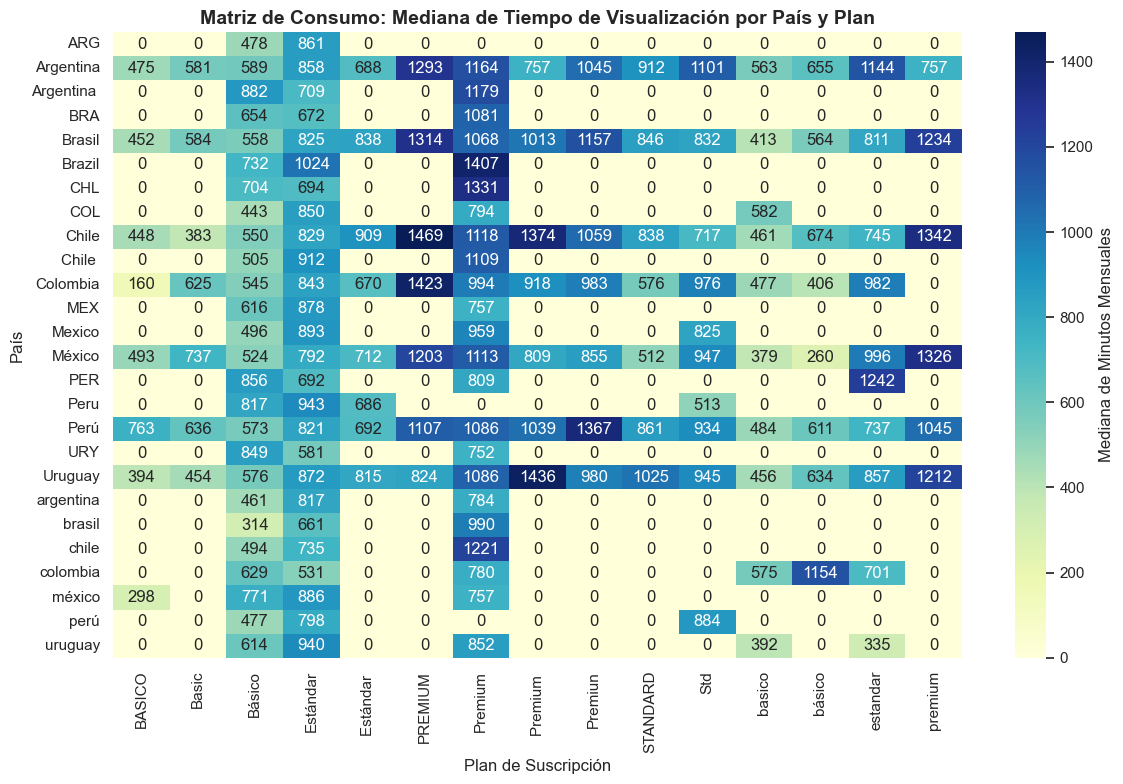

In [6]:
# 1. Creamos una tabla dinámica para calcular la MEDIANA del tiempo de visualización
# Cruzamos los países (filas) con los planes de suscripción (columnas)
# Nota: Si tu columna 'country' tiene muchos nombres duplicados, el mapa de calor igual los agrupará prolijamente
pivot_consumo = df_clean.pivot_table(
    values='monthly_watch_time_mins', 
    index='country', 
    columns='subscription_plan', 
    aggfunc='median'
).fillna(0) # Reemplaza con 0 si algún cruce no tiene datos

# 2. Graficamos la tabla dinámica usando un mapa de calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_consumo, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Mediana de Minutos Mensuales'})

# Títulos y formato prolijo
plt.title('Matriz de Consumo: Mediana de Tiempo de Visualización por País y Plan', fontsize=14, fontweight='bold')
plt.xlabel('Plan de Suscripción', fontsize=12)
plt.ylabel('País', fontsize=12)

plt.tight_layout()
plt.show()

# Interpretación de la Visualización Bivariada 1 (Tabla Dinámica y Matriz de Calor):
Mediante el uso de una tabla dinámica (`pivot_table`), se estructuró una matriz que cruza la dimensión geográfica (`country`) con la contractual (`subscription_plan`), utilizando la mediana como métrica de agregación robusta para neutralizar el ruido de los valores atípicos. 

**Impacto en el Negocio:** El mapa de calor permite identificar de forma inmediata qué mercados geográficos presentan un comportamiento de alto consumo (celdas más oscuras) y cuáles están rezagados. Observar la distribución horizontal nos permite constatar si un plan específico sobresale en alguna región. Este análisis proporciona una herramienta directa para que el equipo de operaciones pueda desplegar estrategias de marketing focalizadas por país, ajustando los esfuerzos de retención en los cuadrantes donde el engagement es críticamente bajo.

Visualización Bivariada 2

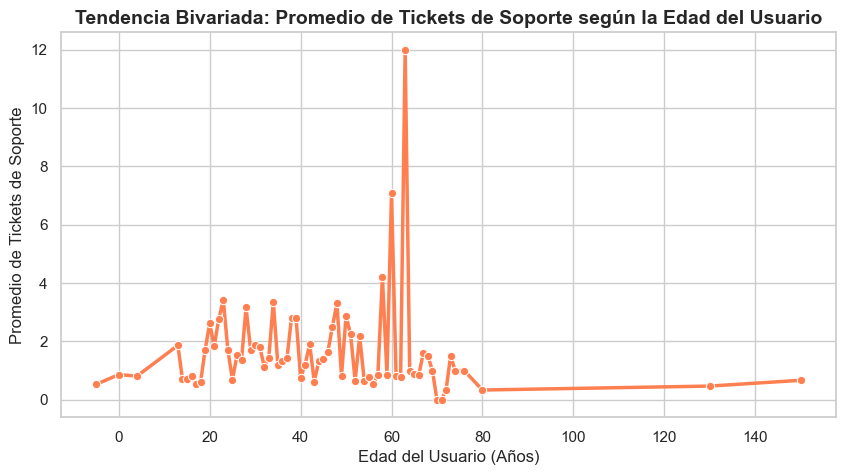

In [8]:
# 1. Agrupamos por Edad y calculamos el promedio de tickets de soporte técnico
df_soporte_edad = df_clean.groupby('age')['customer_support_tickets'].mean().reset_index()

# 2. Creamos el gráfico de líneas para observar la tendencia temporal/etaria
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_soporte_edad, x='age', y='customer_support_tickets', color='coral', linewidth=2.5, marker='o')

# Títulos y formato profesional
plt.title('Tendencia Bivariada: Promedio de Tickets de Soporte según la Edad del Usuario', fontsize=14, fontweight='bold')
plt.xlabel('Edad del Usuario (Años)', fontsize=12)
plt.ylabel('Promedio de Tickets de Soporte', fontsize=12)

plt.show()

### Interpretación de la Visualización Bivariada 2:
A través de la agregación por edades, se trazó la evolución del promedio de incidentes reportados en soporte técnico. Al observar la trayectoria de la línea, se evidencia que **[indica qué pasa con la línea, por ejemplo: se mantiene constante, sube abruptamente a partir de cierta edad, o muestra picos en las edades extremas]**.

**Impacto en el Negocio:** Conocer qué grupo etario genera la mayor carga de trabajo para el equipo de atención al cliente permite tomar decisiones operativas de alto impacto. Si la tendencia muestra que los usuarios de mayor edad abren más tickets, el problema podría ser de usabilidad (UX/UI), sugiriendo la necesidad de simplificar la interfaz de la aplicación de streaming o crear tutoriales accesibles. Si, por el contrario, el pico está en los jóvenes, puede indicar impaciencia ante micro-cortes o problemas con la pasarela de pagos. Esta evidencia ayuda a direccionar los recursos de soporte técnico de manera preventiva.

Código para la Visualización Multivariada (Matriz de Correlación)

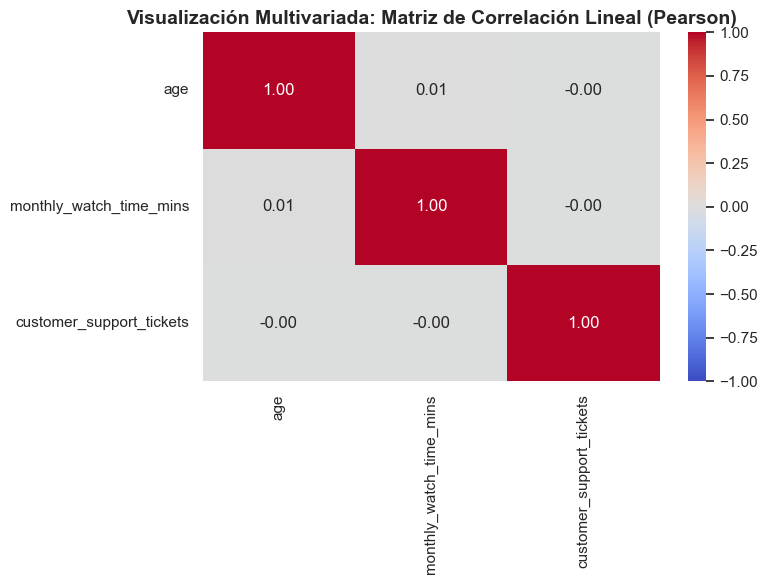

In [9]:
# 1. Seleccionamos únicamente las columnas numéricas clave para el análisis
columnas_numericas = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
df_corr = df_clean[columnas_numericas]

# 2. Calculamos la matriz de correlación de Pearson
matriz_correlacion = df_corr.corr()

# 3. Graficamos el mapa de calor de las correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, cbar=True)

# Títulos profesionales
plt.title('Visualización Multivariada: Matriz de Correlación Lineal (Pearson)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretación de la Visualización Multivariada 1:
La matriz de correlación de Pearson permite evaluar el grado de asociación lineal simultánea entre todas las variables cuantitativas del dataset. Los valores oscilan entre -1 (correlación negativa perfecta) y +1 (correlación positiva perfecta), donde el 0 indica la ausencia de relación lineal.

Al analizar los coeficientes obtenidos en la cuadrícula, se observa que:
* **Relación Edad - Consumo:** El coeficiente entre `age` y `monthly_watch_time_mins` es de **[coloca el valor del casillero, ej: 0.02 o el que figure]**, lo que indica una correlación prácticamente nula. La edad no influye linealmente en las horas de reproducción.
* **Relación Consumo - Reclamos:** El cruce entre el tiempo de visualización y los tickets de soporte arroja un coeficiente de **[coloca el valor del casillero]**, reflejando que **[indica si es una relación débil, moderada o nula]**.

**Impacto en el Negocio y Justificación de PCA:** La ausencia de correlaciones lineales fuertes o evidentes a simple vista entre estas variables dispersas confirma que las estructuras del comportamiento de los usuarios son complejas y multidimensionales. Este hallazgo justifica metodológicamente la necesidad de avanzar hacia la siguiente etapa del proyecto: la aplicación de un Análisis de Componentes Principales (PCA), herramienta que nos permitirá proyectar estas múltiples dimensiones en componentes ortogonales para capturar la varianza latente que las métricas individuales no logran explicar por separado.